## Composite silhouette $S_{mM}$

In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.utils import resample
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


class CompSil:
    """
    Composite Silhouette (CompSil)

    Per subsample b=1..B for each k:
      - compute S_micro^(b), S_macro^(b)
      - Δ_b = S_micro^(b) - S_macro^(b)
      - D = max_b |Δ_b|
      - r_raw_b = Δ_b/(D+eps) in [-1,1]
      - r_b = tanh(r_raw_b)
      - w_b = (1+r_b)/2
      - S_mM^(b) = w_b*S_micro^(b) + (1-w_b)*S_macro^(b)

    Aggregate for each k:
      - mean score:   S_mM(k)  = mean_b S_mM^(b)
      - std score:    std_S_mM(k) = std_b  S_mM^(b)
      - standard error: se_S_mM(k) = std_S_mM(k) / sqrt(B_eff)
      - lower conf bound: LCB_S_mM(k) = S_mM(k) - se_S_mM(k)

    Selection:
      - k* = argmax_k S_mM(k) (or argmax_k LCB_S_mM(k))

    Sampling size mechanism:
      - explicit `sample_size` (int), or
      - sample_size=None or sample_size="auto", the class chooses a subsample size automatically
        based on dataset size N and the maximum k in `k_values`.

    Parameters:
    - data: ndarray or DataFrame, shape (n_samples, n_features)
    - ground_truth: int, optional
    - k_values: iterable or int, default=range(2, 11)
    - num_samples: int, default=100  (B)
    - sample_size: int | float | None | "auto", default=1000
        * int: absolute subsample size m
        * float in (0,1]: treated as fraction f, m = floor(f*N)
        * None or "auto": compute m automatically (see _auto_sample_size)
    - random_state: int, default=42
    - n_jobs: int, default=-1
    - eps: float, default=1e-12
    """

    def __init__(self,
                 data,
                 ground_truth=None,
                 k_values=range(2, 11),
                 num_samples=100,
                 sample_size=1000,
                 random_state=42,
                 n_jobs=-1,
                 eps=1e-12):
        self.data = data
        self.ground_truth = ground_truth
        self.k_values = [k_values] if isinstance(k_values, int) else list(k_values)
        self.num_samples = int(num_samples)
        self.random_state = int(random_state)
        self.n_jobs = int(n_jobs)
        self.eps = float(eps)

        self._results = []
        self.results_df = pd.DataFrame()
        self.score_ = None  # set only if one k is evaluated

        self.n_samples_ = int(len(self.data))
        if self.n_samples_ <= 0:
            raise ValueError("Empty dataset.")

        self.sample_size = self._resolve_sample_size(sample_size)
        self.sample_fraction_ = self.sample_size / self.n_samples_

        if self.sample_size < 2:
            raise ValueError(f"Resolved sample_size={self.sample_size} is too small.")
        if self.sample_size > self.n_samples_:
            raise ValueError(
                f"Resolved sample_size={self.sample_size} is larger than n_samples={self.n_samples_}."
            )

    def _resolve_sample_size(self, sample_size):
        n = self.n_samples_

        # Auto
        if sample_size is None or (isinstance(sample_size, str) and sample_size.lower() == "auto"):
            return self._auto_sample_size()

        # Fraction mode (float in (0,1])
        if isinstance(sample_size, float):
            if not (0.0 < sample_size <= 1.0):
                raise ValueError("If sample_size is a float, it must be in (0, 1].")
            m = int(np.floor(sample_size * n))
            return max(2, min(m, n))

        # Int mode
        m = int(sample_size)
        return m

    def _auto_sample_size(self):
        """
        Automatic subsample size selection (no user-facing hyperparameters).

        Heuristic:
          1) Ensure a minimum average points-per-cluster at k_max: m >= 30 * k_max
          2) Use a baseline fraction depending on dataset size:
             - small N: 0.8N
             - medium N: 0.6N
             - large N: 0.4N
          3) Take the maximum of (1) and (2), then cap at N.
        """
        n = self.n_samples_
        k_max = int(max(self.k_values)) if len(self.k_values) > 0 else 2

        m_min = 30 * k_max

        if n <= 2000:
            m_base = int(np.floor(0.80 * n))
        elif n <= 20000:
            m_base = int(np.floor(0.60 * n))
        else:
            m_base = int(np.floor(0.40 * n))

        m = max(m_min, m_base)
        m = min(max(2, m), n)
        return m

    def evaluate_sample(self, k, i):
        """
        One subsampling iteration for fixed k.
        Returns: (smicro, smacro, diff, s_mm_b)
        """
        seed = self.random_state + i

        sampled_data = resample(
            self.data,
            n_samples=self.sample_size,
            replace=False,
            random_state=seed
        )

        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=1)
        labels = kmeans.fit_predict(sampled_data)

        try:
            s = silhouette_samples(sampled_data, labels)  # compute once
            # micro silhouette
            smicro = float(np.mean(s))
            labs = np.asarray(labels)
            uniq = np.unique(labs)
            cluster_means = [float(np.mean(s[labs == u])) for u in uniq]
            # macro silhouette
            smacro = float(np.mean(cluster_means)) if len(cluster_means) > 0 else np.nan
        except Exception:
            return np.nan, np.nan, np.nan, np.nan

        diff = smicro - smacro
        return smicro, smacro, diff, np.nan

    @staticmethod
    def _tanh_rb_weights_from_differences(differences, eps=1e-12):
        """
        Given Δ_b over b=1..B, compute:
          D       = max |Δ_b|
          r_raw_b = Δ_b/(D+eps) in [-1, 1]
          r_b     = tanh(r_raw_b)
          w_b     = (1+r_b)/2 in (0,1)
        """
        d = np.asarray(differences, dtype=float)
        finite = np.isfinite(d)

        if not np.any(finite):
            return d * np.nan, d * np.nan, np.nan

        D = float(np.max(np.abs(d[finite])))
        denom = D + float(eps)

        if D == 0.0:
            r = np.zeros_like(d)
            r[~finite] = np.nan
            w = 0.5 * np.ones_like(d)
            w[~finite] = np.nan
            return w, r, D

        r_raw = d / denom
        r_raw = np.clip(r_raw, -1.0, 1.0)
        r_raw[~finite] = np.nan

        r = np.tanh(r_raw)
        r[~finite] = np.nan

        w = 0.5 * (1.0 + r)
        w[~finite] = np.nan

        return w, r, D

    def evaluate(self):
        """
        Evaluate over k_values using subsampled clustering.
        Stores results in self.results_df.

        Output columns (per k):
        - avg S_micro
        - avg S_macro
        - w_micro (mean of per-subsample weights; descriptive)
        - S_mM (mean of per-subsample composites)
        - std S_mM
        - se S_mM
        - LCB S_mM  (S_mM - se)
        """
        self._results = []

        for k in self.k_values:
            results = Parallel(n_jobs=self.n_jobs)(
                delayed(self.evaluate_sample)(k, i) for i in range(self.num_samples)
            )

            smicro_list, smacro_list, differences, _ = zip(*results)

            smicro_arr = np.asarray(smicro_list, dtype=float)
            smacro_arr = np.asarray(smacro_list, dtype=float)
            diff_arr = np.asarray(differences, dtype=float)

            avg_smicro = float(np.nanmean(smicro_arr)) if np.any(np.isfinite(smicro_arr)) else np.nan
            avg_smacro = float(np.nanmean(smacro_arr)) if np.any(np.isfinite(smacro_arr)) else np.nan

            # weights
            w_b, r_b, D = self._tanh_rb_weights_from_differences(diff_arr, eps=self.eps)

            # per-subsample composite
            S_b = w_b * smicro_arr + (1.0 - w_b) * smacro_arr

            # mean composite
            S_mM = float(np.nanmean(S_b)) if np.any(np.isfinite(S_b)) else np.nan

            # descriptive mean weight
            w_micro_mean = float(np.nanmean(w_b)) if np.any(np.isfinite(w_b)) else np.nan

            # LCB components computed from S_b across valid subsamples
            finite_sb = np.isfinite(S_b)
            B_eff = int(np.sum(finite_sb))
            if B_eff >= 2:
                std_smm = float(np.nanstd(S_b, ddof=1))
                se_smm = std_smm / np.sqrt(B_eff)
            elif B_eff == 1:
                std_smm = 0.0
                se_smm = 0.0
            else:
                std_smm = np.nan
                se_smm = np.nan

            lcb_smm = (S_mM - se_smm) if (np.isfinite(S_mM) and np.isfinite(se_smm)) else np.nan

            if len(self.k_values) == 1:
                self.score_ = S_mM

            result = {
                'k': int(k),
                'avg S_micro': avg_smicro,
                'avg S_macro': avg_smacro,
                'w_micro': w_micro_mean,
                'S_mM': S_mM,
                'std S_mM': std_smm,
                'se S_mM': se_smm,
                'LCB S_mM': lcb_smm,
                'B_eff': B_eff,
                'sample_size': int(self.sample_size),
                'sample_fraction': float(self.sample_fraction_),
            }
            self._results.append(result)

        self.results_df = pd.DataFrame(self._results)

    def plot_results(self):
        """
        Plot S_mM and individual averages vs k.
        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")
        if len(self.results_df) == 1:
            raise ValueError("Cannot plot with only one k. Evaluate multiple k values.")

        max_smicro = self.results_df['avg S_micro'].max()
        max_smicro_k = self.results_df.loc[self.results_df['avg S_micro'].idxmax(), 'k']

        max_smacro = self.results_df['avg S_macro'].max()
        max_smacro_k = self.results_df.loc[self.results_df['avg S_macro'].idxmax(), 'k']

        max_smm = self.results_df['S_mM'].max()
        max_smm_k = self.results_df.loc[self.results_df['S_mM'].idxmax(), 'k']

        plt.figure(figsize=(10, 4))

        if self.ground_truth is not None:
            plt.axvline(
                x=self.ground_truth, color='red', linestyle='--', linewidth=2.5,
                label='Ground Truth'
            )

        plt.plot(
            self.results_df['k'], self.results_df['avg S_micro'],
            marker='o', linestyle='-', color='orange', linewidth=4, markersize=8, label='avg S_micro'
        )
        plt.plot(max_smicro_k, max_smicro, marker='*', color='orange', markersize=18)

        plt.plot(
            self.results_df['k'], self.results_df['avg S_macro'],
            marker='o', linestyle='-', color='blue', linewidth=4, markersize=8, label='avg S_macro'
        )
        plt.plot(max_smacro_k, max_smacro, marker='*', color='blue', markersize=18)

        plt.plot(
            self.results_df['k'], self.results_df['S_mM'],
            marker='o', linestyle='--', color='green', linewidth=4, markersize=8, label='S_mM'
        )
        plt.plot(max_smm_k, max_smm, marker='*', color='green', markersize=18)

        plt.xlabel('k', fontsize=15)
        plt.xticks(self.k_values, fontsize=14)
        plt.yticks(fontsize=14)
        plt.tick_params(axis='y', which='both', length=0)
        plt.grid(axis='y', linestyle='--')

        ax = plt.gca()
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            loc="lower left",
            bbox_to_anchor=(0, 1.02, 1, 0.2),
            mode="expand",
            ncol=len(labels),
            frameon=False,
            fontsize=12
        )

        plt.tight_layout()
        plt.show()

    def get_optimal_k(self, use_lcb=False):
        """
        Return optimal k.

        By default, uses max selection:
          k* = argmax_k (S_mM) (use_lcb for argmax_k (LCB S_mM) selection)

        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")

        if len(self.results_df) == 1:
            return int(self.results_df['k'].iloc[0])

        col = 'LCB S_mM' if use_lcb else 'S_mM'
        if col not in self.results_df.columns:
            raise ValueError(f"Missing column '{col}'. Run evaluate() first.")

        optimal_row = self.results_df.loc[self.results_df[col].idxmax()]
        return int(optimal_row['k'])

    def get_results_dataframe(self):
        """
        Return results DataFrame indexed by k.
        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")
        return self.results_df.set_index('k', inplace=False)

### Helpers

In [2]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
)

def argmax_k_and_value(df, col):
    idx = df[col].idxmax()
    if "k" in df.columns:
        k = int(df.loc[idx, "k"])
    else:
        k = int(idx)
    v = float(df.loc[idx, col])
    return k, v

def _silhouette_macro(X, labels):
    """Macro silhouette = mean over clusters of (cluster mean silhouette)."""
    s = silhouette_samples(X, labels)
    labs = np.asarray(labels)
    uniq = np.unique(labs)

    means = []
    for u in uniq:
        m = (labs == u)
        if np.any(m):
            means.append(float(np.mean(s[m])))

    return float(np.mean(means)) if means else np.nan


def mean_metrics_over_runs_choose_k(
    X,
    num_runs,
    k_values=range(2, 11),
    random_state=42,
    kmeans_n_init=1,
):
    """
    Full-data repeated KMeans runs to estimate k by mean internal indices.

    For each k in k_values:
      - run KMeans num_runs times on full X (seed = random_state + run_id)
      - compute micro silhouette, macro silhouette, CH, DB
      - take mean across runs for each metric

    Select k by:
      - micro: argmax mean micro silhouette
      - macro: argmax mean macro silhouette
      - CH:    argmax mean CH
      - DB:    argmin mean DB

    Returns
    -------
    result : dict
        {
          'k_micro', 'mean_micro_at_k_micro',
          'k_macro', 'mean_macro_at_k_macro',
          'k_ch',    'mean_ch_at_k_ch',
          'k_db',    'mean_db_at_k_db',
          'means_df'  (pd.DataFrame per k)
        }
    """
    X_arr = np.asarray(X)
    n = int(X_arr.shape[0])

    k_list = [k_values] if isinstance(k_values, int) else list(k_values)
    if len(k_list) == 0:
        raise ValueError("k_values must contain at least one value.")
    if int(num_runs) < 1:
        raise ValueError("num_runs must be >= 1.")

    rows = []
    for k in k_list:
        k = int(k)
        if k < 2 or k >= n:
            rows.append({
                "k": k,
                "mean_micro": np.nan,
                "mean_macro": np.nan,
                "mean_ch": np.nan,
                "mean_db": np.nan,
                "runs_used": 0,
            })
            continue

        micro_vals, macro_vals, ch_vals, db_vals = [], [], [], []

        for i in range(int(num_runs)):
            seed = int(random_state) + i
            km = KMeans(n_clusters=k, random_state=seed, n_init=int(kmeans_n_init))
            labels = km.fit_predict(X_arr)

            try:
                micro_vals.append(float(silhouette_score(X_arr, labels)))
            except Exception:
                micro_vals.append(np.nan)

            try:
                macro_vals.append(float(_silhouette_macro(X_arr, labels)))
            except Exception:
                macro_vals.append(np.nan)

            try:
                ch_vals.append(float(calinski_harabasz_score(X_arr, labels)))
            except Exception:
                ch_vals.append(np.nan)

            try:
                db_vals.append(float(davies_bouldin_score(X_arr, labels)))
            except Exception:
                db_vals.append(np.nan)

        micro_vals = np.asarray(micro_vals, dtype=float)
        macro_vals = np.asarray(macro_vals, dtype=float)
        ch_vals = np.asarray(ch_vals, dtype=float)
        db_vals = np.asarray(db_vals, dtype=float)

        rows.append({
            "k": k,
            "mean_micro": float(np.nanmean(micro_vals)) if np.any(np.isfinite(micro_vals)) else np.nan,
            "mean_macro": float(np.nanmean(macro_vals)) if np.any(np.isfinite(macro_vals)) else np.nan,
            "mean_ch": float(np.nanmean(ch_vals)) if np.any(np.isfinite(ch_vals)) else np.nan,
            "mean_db": float(np.nanmean(db_vals)) if np.any(np.isfinite(db_vals)) else np.nan,
            "runs_used": int(num_runs),
        })

    means_df = pd.DataFrame(rows)

    def _pick_max(col):
        v = means_df[col].to_numpy(dtype=float)
        if not np.any(np.isfinite(v)):
            return np.nan, np.nan
        idx = int(np.nanargmax(v))
        return int(means_df.loc[idx, "k"]), float(means_df.loc[idx, col])

    def _pick_min(col):
        v = means_df[col].to_numpy(dtype=float)
        if not np.any(np.isfinite(v)):
            return np.nan, np.nan
        idx = int(np.nanargmin(v))
        return int(means_df.loc[idx, "k"]), float(means_df.loc[idx, col])

    k_micro, v_micro = _pick_max("mean_micro")
    k_macro, v_macro = _pick_max("mean_macro")
    k_ch, v_ch = _pick_max("mean_ch")
    k_db, v_db = _pick_min("mean_db")

    return {
        "k_micro": k_micro,
        "mean_micro_at_k_micro": v_micro,
        "k_macro": k_macro,
        "mean_macro_at_k_macro": v_macro,
        "k_ch": k_ch,
        "mean_ch_at_k_ch": v_ch,
        "k_db": k_db,
        "mean_db_at_k_db": v_db,
        "means_df": means_df,
    }

## Data

##### imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    fetch_openml,
    fetch_20newsgroups,
    load_iris,
    load_wine,
    load_digits,
    load_breast_cancer,
    make_blobs,
)

from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize, Normalizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.datasets import cifar10, fashion_mnist

!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

import seaborn as sns
from torchvision.datasets import STL10
from torchvision import transforms, models
import torch

import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

### Synthetic Datasets

In [4]:
# Synthetic 1
data_1, true_labels_1 = make_blobs(n_samples=10000, centers=5, cluster_std=0.5, random_state=100)
scaler = StandardScaler()

s1 = scaler.fit_transform(data_1)
name_s1 = "S1"
k_s1 = 5

# Synthetic 2
data_2, true_labels_2 = make_blobs(n_samples=10000, centers=6, cluster_std=0.9, random_state=20)
scaler = StandardScaler()

s2 = scaler.fit_transform(data_2)
name_s2 = "S2"
k_s2 = 6

# Synthetic 3
cluster_sizes_3 = [1000, 1000, 100, 100, 100]  # 2 large, 3 small
centers_3 = [
    (0, 0),   # large cluster #1
    (3, 3),   # large cluster #2 (not too far from #1, so they merge in small k)
    (12, 12), # small cluster #1
    (-12, 12),# small cluster #2
    (0, 15),  # small cluster #3
]
stds = [1.8, 1.8, 0.5, 0.5, 0.5]  # bigger std for large clusters, smaller for small

X_3, y_3 = make_blobs(
    n_samples=cluster_sizes_3,
    centers=centers_3,
    cluster_std=stds,
    random_state=42
)

scaler = StandardScaler()

s3 = scaler.fit_transform(X_3)
name_s3 = "S3"
k_s3 = 5

# Synthetic 4
cluster_sizes_4 = [1500, 1500, 300, 300] + [80]*5 + [30]*3
# 4 (big+medium) + 5 small + 3 tiny = 12 clusters

centers_4 = [
    # Large clusters near each other
    (0, 0),        # Large #1
    (3, 3),        # Large #2

    # Medium clusters
    (8, 0),        # Medium #1
    (0, 8),        # Medium #2

    # 5 small clusters
    (18, 18),
    (-18, 18),
    (18, -18),
    (-18, -18),
    (22, 0),

    # 3 tiny clusters placed very far away
    (0, 25),
    (25, 25),
    (25, -25)
]

# Standard deviations
# - Large clusters bigger spread
# - Medium smaller
# - Small even smaller
# - Tiny very small spread
stds_4 = [
    2.2, 2.2,   # large
    1.2, 1.2,   # medium
    0.9, 0.9, 0.9, 0.9, 0.9,  # 5 small
    0.6, 0.6, 0.6             # 3 tiny
]

X_4, y_4 = make_blobs(
    n_samples=cluster_sizes_4,
    centers=centers_4,
    cluster_std=stds_4,
    random_state=47
)

scaler = StandardScaler()

s4 = scaler.fit_transform(X_4)
name_s4 = "S4"
k_s4 = 12

In [5]:
synthetic_datasets = {
    name_s1: (s1, k_s1),
    name_s2: (s2, k_s2),
    name_s3: (s3, k_s3),
    name_s4: (s4, k_s4)
}

print(list(synthetic_datasets.keys()))

['S1', 'S2', 'S3', 'S4']


#### Visualization

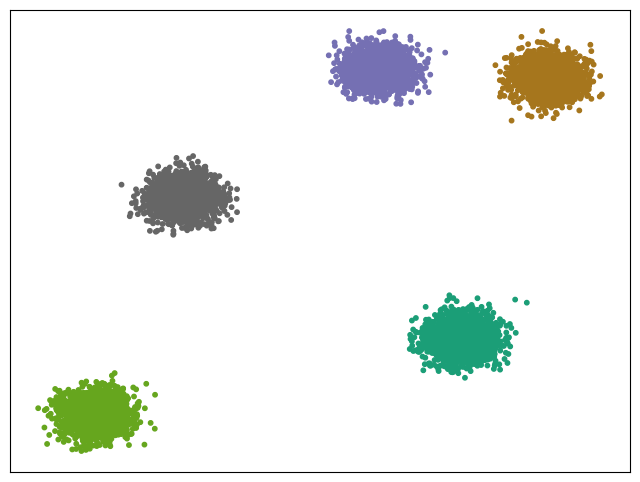

In [6]:
# S1
plt.figure(figsize=(8,6))
plt.scatter(s1[:, 0], s1[:, 1], c=true_labels_1, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

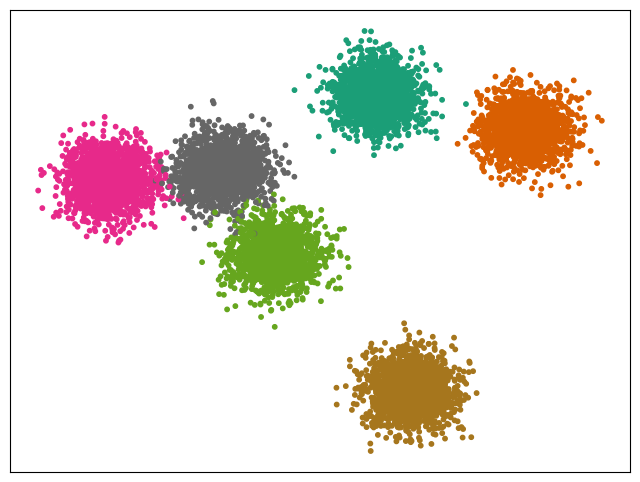

In [7]:
# S2
plt.figure(figsize=(8,6))
plt.scatter(s2[:, 0], s2[:, 1], c=true_labels_2, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

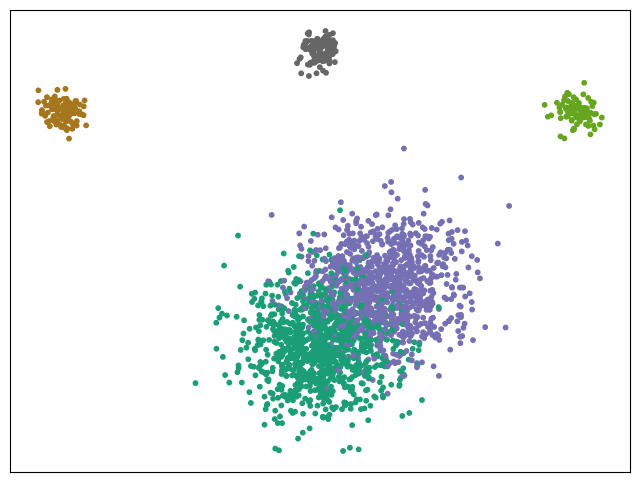

In [8]:
# S3
plt.figure(figsize=(8,6))
plt.scatter(s3[:, 0], s3[:, 1], c=y_3, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

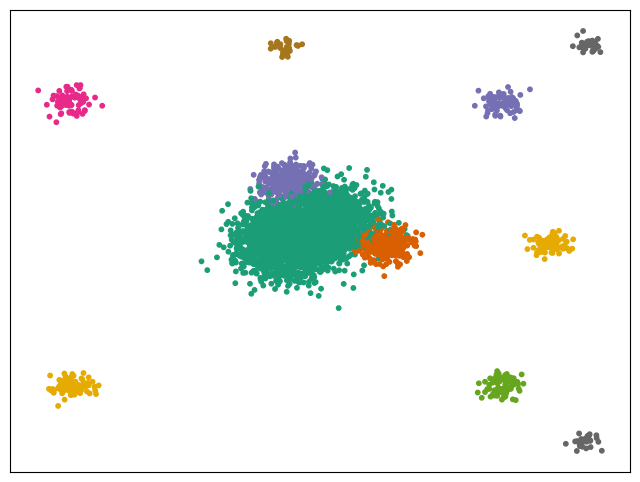

In [9]:
# S4
plt.figure(figsize=(8,6))
plt.scatter(s4[:, 0], s4[:, 1], c=y_4, s=10, cmap='Dark2')
plt.xticks([])
plt.yticks([])
plt.show()

### Real datasets

In [10]:
# Parkinsons
data_parkinson = fetch_openml(name='parkinsons', version=1, as_frame=True)
X_parkinson = data_parkinson.data
y_parkinson_raw = data_parkinson.target

le_parkinson = LabelEncoder()
y_parkinson = le_parkinson.fit_transform(y_parkinson_raw)
num_classes_parkinson = len(np.unique(y_parkinson))

X_park = StandardScaler().fit_transform(X_parkinson)
name_park = "Pks"
k_park = num_classes_parkinson

# Blood Transfusion
data_blood = fetch_openml(name='blood-transfusion-service-center', version=1, as_frame=True)
X_blood = data_blood.data
y_blood_raw = data_blood.target

le = LabelEncoder()
y_blood = le.fit_transform(y_blood_raw)
num_classes_blood = len(np.unique(y_blood))

X_blood_scaled = StandardScaler().fit_transform(X_blood)

X_blood = X_blood_scaled
name_blood = "Bld"
k_blood = num_classes_blood

# HTRU2
htru2 = fetch_ucirepo(id=372)
X_htru2 = htru2.data.features.to_numpy()
y_raw_htru2 = htru2.data.targets.iloc[:, 0]  # Single binary column

le_htru2 = LabelEncoder()
y_htru2 = le_htru2.fit_transform(y_raw_htru2)
num_classes_htru2 = len(np.unique(y_htru2))

X_htr= StandardScaler().fit_transform(X_htru2)
name_htr = "htr"
k_htr = num_classes_htru2

# Spambase
data_spambase = fetch_openml(name='spambase', version=1, as_frame=True)
X_spambase = data_spambase.data
y_spambase_raw = data_spambase.target

le_spam = LabelEncoder()
y_spambase = le_spam.fit_transform(y_spambase_raw)
num_classes_spambase = len(np.unique(y_spambase))

X_spam = StandardScaler().fit_transform(X_spambase)
name_spam = "Spm"
k_spam = num_classes_spambase

# Bank Marketing
data_bank = fetch_openml(name='bank-marketing', version=1, as_frame=True)
X_bank = data_bank.data.select_dtypes(include=[np.number])  # numeric features only
y_bank_raw = data_bank.target

le_bank = LabelEncoder()
y_bank = le_bank.fit_transform(y_bank_raw)
num_classes_bank = len(np.unique(y_bank))

X_bank = StandardScaler().fit_transform(X_bank)
name_bank = "Bnk"
k_bank = num_classes_bank

# Wine
data_wine = load_wine()
X_wine = data_wine.data
y_wine = data_wine.target

scaler = StandardScaler()

X_wine = scaler.fit_transform(X_wine)
name_wine = "Wne"
k_wine = len(set(y_wine))

# Digits
data_digits = load_digits()
X_digits = data_digits.data

pca = PCA(n_components=0.999)
X_digits = pca.fit_transform(X_digits)
name_digits = "Dgt"
k_digits = 10

# 20 Newsgroups
data_20ng = fetch_20newsgroups(subset='train')
num_classes_20ng = 20

vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(data_20ng.data)

svd = TruncatedSVD(n_components=50, random_state=0)
X_svd = svd.fit_transform(X_tfidf)

X_ng = X_svd
name_ng = "Nsg"
k_ng = num_classes_20ng

# STL-10
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = torch.nn.Identity()  # remove classification head
model.eval()

transform = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

dataset = STL10(root='data', split='train', download=True, transform=transform)

features, labels = [], []
with torch.no_grad():
    for img, label in dataset:
        f = model(img.unsqueeze(0)).squeeze().numpy()
        features.append(f)
        labels.append(label)

X_stl = np.array(features)
y_stl = np.array(labels)
num_classes_stl = len(np.unique(y_stl))

X_stl_scaled = StandardScaler().fit_transform(X_stl)

X_stl = X_stl_scaled
name_stl = "Stl"
k_stl = num_classes_stl

# BBC
bbc_ds = load_dataset("SetFit/bbc-news")
train_ds_bbc = bbc_ds["train"]
test_ds_bbc  = bbc_ds["test"]

texts_bbc = list(train_ds_bbc["text"]) + list(test_ds_bbc["text"])
labels_raw_bbc = list(train_ds_bbc["label"]) + list(test_ds_bbc["label"])
label_texts_bbc = list(train_ds_bbc["label_text"]) + list(test_ds_bbc["label_text"])

y_bbc = np.array(labels_raw_bbc, dtype=int)
k_bbc = len(np.unique(y_bbc))

label_map = {}
for lab, lab_txt in zip(labels_raw_bbc, label_texts_bbc):
    lab = int(lab)
    if lab not in label_map:
        label_map[lab] = lab_txt

model = SentenceTransformer("all-MiniLM-L6-v2")
X_embed_bbc = model.encode(
    texts_bbc,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)

pca = PCA(n_components=50, random_state=0)
X_bbc_embed_50 = pca.fit_transform(X_embed_bbc)

X_bbc = X_bbc_embed_50
name_bbc = "Bbc"
k_bbc = len(np.unique(y_bbc))

# Minds-14
encoder_minilm = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def build_minilm_pca_features(
    texts,
    n_components=50,
    encoder=encoder_minilm,
    random_state=0,
):
    """
    texts -> MiniLM embeddings -> PCA(n_components) -> L2-normalized
    """
    X_emb = encoder.encode(
        list(map(str, texts)),
        convert_to_numpy=True,
        show_progress_bar=True
    ).astype(np.float64)

    pca = PCA(
        n_components=n_components,
        whiten=False,
        random_state=random_state
    )
    X_pca = pca.fit_transform(X_emb)

    normalizer = Normalizer(norm="l2", copy=False)
    X_final = normalizer.fit_transform(X_pca)

    return X_final, pca, normalizer

ds_minds_train = load_dataset("DeepPavlov/minds14", split="train")
ds_minds_test  = load_dataset("DeepPavlov/minds14", split="test")

texts_minds = (
    list(map(str, ds_minds_train["utterance"])) +
    list(map(str, ds_minds_test["utterance"]))
)
labels_minds_raw = (
    list(ds_minds_train["label"]) +
    list(ds_minds_test["label"])
)

le_minds = LabelEncoder()
y_minds = le_minds.fit_transform(labels_minds_raw)
k_minds = len(np.unique(y_minds))

X_minds_minilm, pca_minds, norm_minds_emb = build_minilm_pca_features(
    texts_minds,
    n_components=85,
    encoder=encoder_minilm,
    random_state=0,
)

X_minds = X_minds_minilm
name_minds = "Mds"
k_minds = len(np.unique(y_minds))

# Banking 77
ds_train = load_dataset("PolyAI/banking77", split="train", revision="refs/convert/parquet")
ds_test  = load_dataset("PolyAI/banking77", split="test",  revision="refs/convert/parquet")

texts_b77 = list(map(str, ds_train["text"])) + list(map(str, ds_test["text"]))
labels_b77_raw = list(ds_train["label"]) + list(ds_test["label"])

le = LabelEncoder()
y_b77 = le.fit_transform(labels_b77_raw)

k_b77 = len(np.unique(y_b77))

encoder_b77 = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
X_b77_embed = encoder_b77.encode(
    texts_b77,
    convert_to_numpy=True,
    show_progress_bar=False
).astype(np.float64)

pca_b77 = PCA(
    n_components=50,
    whiten=False,
    random_state=0
)
X_b77_pca = pca_b77.fit_transform(X_b77_embed)

normalizer = Normalizer(norm="l2", copy=False)
X_b77 = normalizer.fit_transform(X_b77_pca)

pca_b77 = PCA(
    n_components=50,
    whiten=False,
    random_state=0
)

X_b77_pca = pca_b77.fit_transform(X_b77_embed)

normalizer = Normalizer(norm="l2", copy=False)

X_b77 = normalizer.fit_transform(X_b77_pca)
name_b77 = "B77"
k_b77 = len(np.unique(y_b77))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 216MB/s]
100%|██████████| 2.64G/2.64G [03:20<00:00, 13.2MB/s]


README.md:   0%|          | 0.00/880 [00:00<?, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

...

0000.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
real_datasets = {
    name_park: (X_park, k_park),
    name_blood: (X_blood, k_blood),
    name_htr: (X_htr, k_htr),
    name_spam: (X_spam, k_spam),
    name_bank: (X_bank, k_bank),
    name_wine: (X_wine, k_wine),
    name_digits: (X_digits, k_digits),
    name_ng: (X_ng, k_ng),
    name_stl: (X_stl, k_stl),
    name_bbc: (X_bbc, k_bbc),
    name_minds: (X_minds, k_minds),
    name_b77: (X_b77, k_b77)
}

print(list(real_datasets.keys()))

['Pks', 'Bld', 'htr', 'Spm', 'Bnk', 'Wne', 'Dgt', 'Nsg', 'Stl', 'Bbc', 'Mds', 'B77']


In [12]:
all_sets = {**synthetic_datasets, **real_datasets}
#print(list(all_sets.keys()))

## $S_{mM}$ vs. number of samples

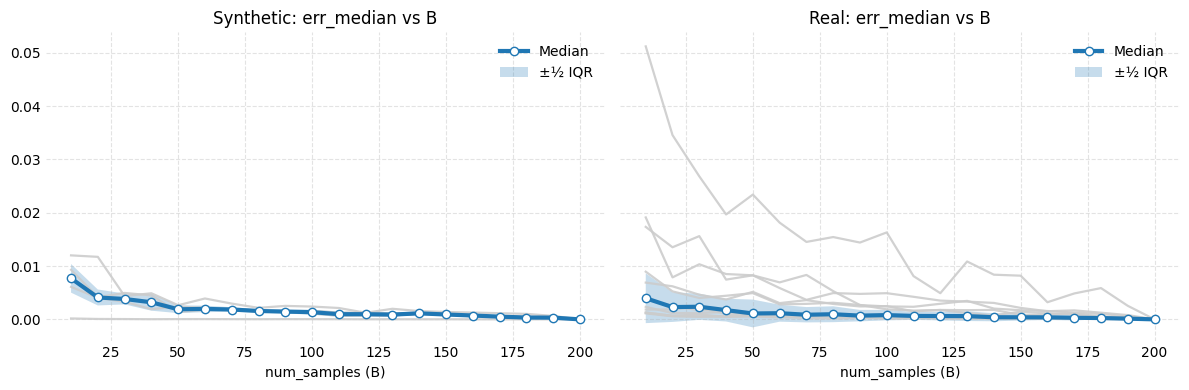

In [13]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.utils import resample
from joblib import Parallel, delayed


def _iqr(x):
    x = np.asarray(x, dtype=float)
    q25, q75 = np.percentile(x, [25, 75])
    return float(q75 - q25)


def _auto_sample_size(n, k_max):

    m_min = 30 * int(k_max)
    if n <= 2000:
        m_base = int(np.floor(0.80 * n))
    elif n <= 20000:
        m_base = int(np.floor(0.60 * n))
    else:
        m_base = int(np.floor(0.40 * n))
    m = max(m_min, m_base)
    m = min(max(2, m), n)
    return int(m)


def _silhouette_macro(X, labels):
    s = silhouette_samples(X, labels)
    labs = np.asarray(labels)
    uniq = np.unique(labs)
    means = []
    for u in uniq:
        m = (labs == u)
        if np.any(m):
            means.append(float(np.mean(s[m])))
    return float(np.mean(means)) if means else np.nan


def _tanh_rb_weights_from_differences(differences, eps=1e-12):
    d = np.asarray(differences, dtype=float)
    finite = np.isfinite(d)
    if not np.any(finite):
        return d * np.nan, d * np.nan, np.nan

    D = float(np.max(np.abs(d[finite])))
    denom = D + float(eps)

    if D == 0.0:
        r = np.zeros_like(d)
        r[~finite] = np.nan
        w = 0.5 * np.ones_like(d)
        w[~finite] = np.nan
        return w, r, D

    r_raw = d / denom
    r_raw = np.clip(r_raw, -1.0, 1.0)
    r_raw[~finite] = np.nan

    r = np.tanh(r_raw)
    r[~finite] = np.nan

    w = 0.5 * (1.0 + r)
    w[~finite] = np.nan
    return w, r, D


def _pool_one_subsample(X, k_gt, sample_size, seed):
    # One subsample draw + KMeans + (micro, macro, diff)
    Xs = resample(X, n_samples=int(sample_size), replace=False, random_state=int(seed))
    km = KMeans(n_clusters=int(k_gt), random_state=int(seed), n_init=1)
    labels = km.fit_predict(Xs)

    try:
        smicro = float(silhouette_score(Xs, labels))
        smacro = float(_silhouette_macro(Xs, labels))
        diff = smicro - smacro
        return smicro, smacro, diff
    except Exception:
        return np.nan, np.nan, np.nan


def _compute_SmM_from_arrays(smicro_arr, smacro_arr, diff_arr, eps=1e-12):
    w_b, r_b, D = _tanh_rb_weights_from_differences(diff_arr, eps=eps)
    S_b = w_b * smicro_arr + (1.0 - w_b) * smacro_arr
    finite_sb = np.isfinite(S_b)
    if not np.any(finite_sb):
        return np.nan, np.nan, np.nan, 0
    S_mM = float(np.nanmean(S_b))
    std_smm = float(np.nanstd(S_b, ddof=1)) if int(np.sum(finite_sb)) >= 2 else 0.0
    se_smm = std_smm / np.sqrt(int(np.sum(finite_sb))) if int(np.sum(finite_sb)) >= 2 else 0.0
    B_eff = int(np.sum(finite_sb))
    return S_mM, std_smm, se_smm, B_eff


def compsil_subensemble_convergence_one_dataset(
    X,
    k_gt,
    B_grid=(10, 20, 40, 60, 80, 100),
    B_max=100,
    R=25,
    random_state=42,
    n_jobs=-1,
    eps=1e-12,
):

    X = np.asarray(X)
    n = X.shape[0]
    k_gt = int(max(2, min(int(k_gt), n - 1)))

    B_max = int(B_max)
    B_grid = tuple(int(b) for b in B_grid)
    if max(B_grid) > B_max:
        raise ValueError(f"max(B_grid)={max(B_grid)} must be <= B_max={B_max}")

    sample_size = _auto_sample_size(n=n, k_max=k_gt)
    sample_fraction = sample_size / float(n)

    t0 = time.perf_counter()
    pool = Parallel(n_jobs=int(n_jobs))(
        delayed(_pool_one_subsample)(X, k_gt, sample_size, int(random_state) + i)
        for i in range(B_max)
    )
    pool_build_sec = time.perf_counter() - t0

    smicro_pool = np.asarray([p[0] for p in pool], dtype=float)
    smacro_pool = np.asarray([p[1] for p in pool], dtype=float)
    diff_pool   = np.asarray([p[2] for p in pool], dtype=float)

    # reference uses ALL B_max
    ref_SmM, ref_std, ref_se, ref_Beff = _compute_SmM_from_arrays(
        smicro_pool, smacro_pool, diff_pool, eps=eps
    )

    rng = np.random.default_rng(int(random_state))

    rows = []
    for B in sorted(B_grid):
        B = int(B)

        if B == B_max:
            SmM_B = ref_SmM
            err_vals = np.array([0.0], dtype=float)
        else:
            err_vals = []
            for r in range(int(R)):
                idx = rng.choice(B_max, size=B, replace=False)
                SmM_B, _, _, _ = _compute_SmM_from_arrays(
                    smicro_pool[idx], smacro_pool[idx], diff_pool[idx], eps=eps
                )
                err_vals.append(abs(SmM_B - ref_SmM))
            err_vals = np.asarray(err_vals, dtype=float)

        rows.append({
            "B": B,
            "ref_SmM_Bmax": float(ref_SmM),
            "err_median": float(np.nanmedian(err_vals)),
            "err_iqr": float(_iqr(err_vals)),
            "err_mean": float(np.nanmean(err_vals)),
            "sample_size": int(sample_size),
            "sample_fraction": float(sample_fraction),
            "pool_build_sec": float(pool_build_sec),
            "B_max": int(B_max),
            "R": int(R),
        })

    return pd.DataFrame(rows)


def build_convergence_df_subensemble(
    datasets_dict,  # name -> (X, k_gt)
    B_grid=(10, 20, 40, 60, 80, 100),
    B_max=100,
    R=25,
    random_state=42,
    n_jobs=-1,
):
    all_rows = []
    for name, (X, k_gt) in datasets_dict.items():
        df = compsil_subensemble_convergence_one_dataset(
            X=X,
            k_gt=k_gt,
            B_grid=B_grid,
            B_max=B_max,
            R=R,
            random_state=random_state,
            n_jobs=n_jobs,
        )
        df["dataset"] = name
        df["k_gt"] = int(k_gt)
        all_rows.append(df)
    return pd.concat(all_rows, ignore_index=True)


def summarize_convergence(conv_df, value_col="err_median"):
    agg = conv_df.groupby("B", as_index=False).agg(
        median=(value_col, "median"),
        iqr=(value_col, _iqr),
    )
    per_ds = conv_df.pivot_table(index=["dataset", "B"], values=[value_col]).reset_index()
    return agg, per_ds


def plot_two_panel_convergence(per_ds_synth, agg_synth, per_ds_real, agg_real,
                               value_col="err_median",
                               ylabel="|S_mM(B) - S_mM(B_max)|  (↓)",
                               title_left="Synthetic", title_right="Real"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    def panel(ax, per_ds, agg, title, show_ylabel=False):
        for ds, g in per_ds.groupby("dataset"):
            ax.plot(g["B"], g[value_col], color="0.8", linewidth=1.6, alpha=0.9)

        ax.plot(
            agg["B"], agg["median"],
            marker="o", markerfacecolor="white",
            linewidth=3, label="Median"
        )
        ax.fill_between(
            agg["B"],
            agg["median"] - 0.5 * agg["iqr"],
            agg["median"] + 0.5 * agg["iqr"],
            alpha=0.25, label="±½ IQR"
        )

        ax.set_title(title)
        ax.set_xlabel("num_samples (B)")
        if show_ylabel:
            ax.set_ylabel(ylabel)

        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(frameon=False, loc="upper right")
        for side in ["top", "right", "left", "bottom"]:
            ax.spines[side].set_visible(False)
        ax.tick_params(axis="both", length=0)

    panel(axes[0], per_ds_synth, agg_synth, f"{title_left}: {value_col} vs B", show_ylabel=True)
    panel(axes[1], per_ds_real,  agg_real,  f"{title_right}: {value_col} vs B", show_ylabel=False)

    plt.tight_layout()
    plt.show()

B_max  = 200
B_grid = (10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200) # 90, 110, 130, 150, 170, 190
R      = 25

conv_df_synth = build_convergence_df_subensemble(
    synthetic_datasets, B_grid=B_grid, B_max=B_max, R=R, random_state=42, n_jobs=-1
)
conv_df_real = build_convergence_df_subensemble(
    real_datasets, B_grid=B_grid, B_max=B_max, R=R, random_state=42, n_jobs=-1
)

agg_synth, per_ds_synth = summarize_convergence(conv_df_synth, value_col="err_median")
agg_real,  per_ds_real  = summarize_convergence(conv_df_real,  value_col="err_median")

plot_two_panel_convergence(
    per_ds_synth, agg_synth,
    per_ds_real,  agg_real,
    value_col="err_median",
    ylabel="",
    title_left="Synthetic",
    title_right="Real",
)

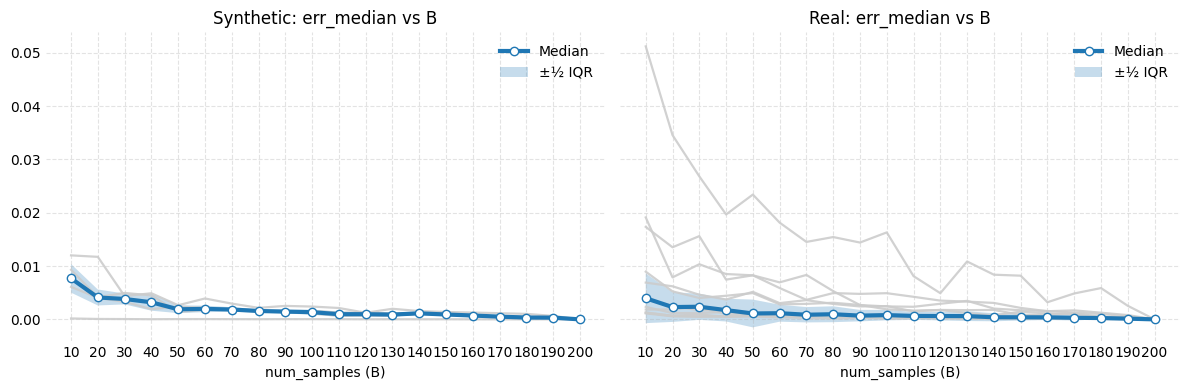

In [14]:
def plot_two_panel_convergence(per_ds_synth, agg_synth, per_ds_real, agg_real,
                               value_col="err_median",
                               ylabel="|S_mM(B) - S_mM(B_max)|  (↓)",
                               title_left="Synthetic", title_right="Real",
                               B_grid=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    def panel(ax, per_ds, agg, title, show_ylabel=False):
        for ds, g in per_ds.groupby("dataset"):
            ax.plot(g["B"], g[value_col], color="0.8", linewidth=1.6, alpha=0.9)

        ax.plot(
            agg["B"], agg["median"],
            marker="o", markerfacecolor="white",
            linewidth=3, label="Median"
        )
        ax.fill_between(
            agg["B"],
            agg["median"] - 0.5 * agg["iqr"],
            agg["median"] + 0.5 * agg["iqr"],
            alpha=0.25, label="±½ IQR"
        )

        ax.set_title(title)
        ax.set_xlabel("num_samples (B)")
        if show_ylabel:
            ax.set_ylabel(ylabel)

        if B_grid is not None:
            ax.set_xticks(list(B_grid))

        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(frameon=False, loc="upper right")
        for side in ["top", "right", "left", "bottom"]:
            ax.spines[side].set_visible(False)
        ax.tick_params(axis="both", length=0)

    panel(axes[0], per_ds_synth, agg_synth, f"{title_left}: {value_col} vs B", show_ylabel=True)
    panel(axes[1], per_ds_real,  agg_real,  f"{title_right}: {value_col} vs B", show_ylabel=False)

    plt.tight_layout()
    plt.show()


plot_two_panel_convergence(
    per_ds_synth, agg_synth,
    per_ds_real,  agg_real,
    value_col="err_median",
    ylabel="",
    title_left="Synthetic",
    title_right="Real",
    B_grid=B_grid,
)

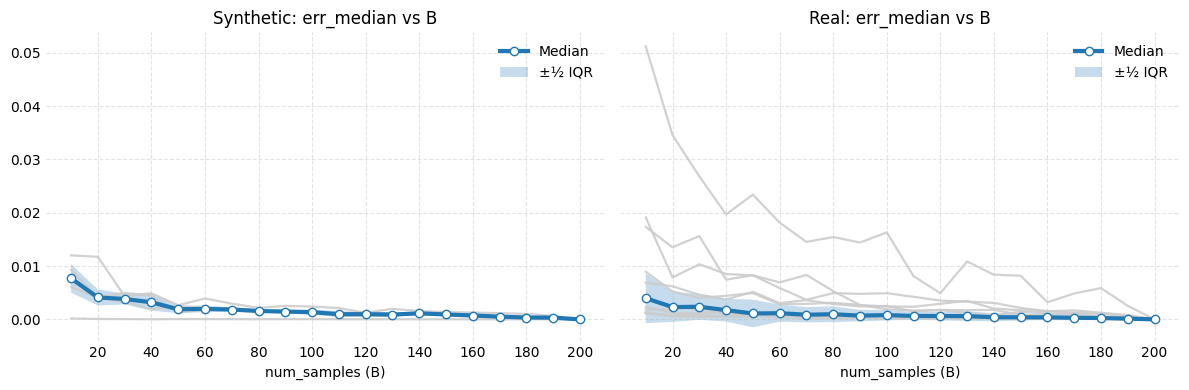

In [15]:
def plot_two_panel_convergence(per_ds_synth, agg_synth, per_ds_real, agg_real,
                               value_col="err_median",
                               ylabel="|S_mM(B) - S_mM(B_max)|  (↓)",
                               title_left="Synthetic", title_right="Real",
                               B_grid=None):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    def panel(ax, per_ds, agg, title, show_ylabel=False):
        for ds, g in per_ds.groupby("dataset"):
            ax.plot(g["B"], g[value_col],
                    color="0.8", linewidth=1.6, alpha=0.9)

        ax.plot(
            agg["B"], agg["median"],
            marker="o", markerfacecolor="white",
            linewidth=3, label="Median"
        )

        ax.fill_between(
            agg["B"],
            agg["median"] - 0.5 * agg["iqr"],
            agg["median"] + 0.5 * agg["iqr"],
            alpha=0.25, label="±½ IQR"
        )

        ax.set_title(title)
        ax.set_xlabel("num_samples (B)")

        if show_ylabel:
            ax.set_ylabel(ylabel)

        if B_grid is not None:
            ticks = [b for b in B_grid if b % 20 == 0]
            ax.set_xticks(ticks)

        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(frameon=False, loc="upper right")

        for side in ["top", "right", "left", "bottom"]:
            ax.spines[side].set_visible(False)

        ax.tick_params(axis="both", length=0)

    panel(axes[0], per_ds_synth, agg_synth,
          f"{title_left}: {value_col} vs B",
          show_ylabel=True)

    panel(axes[1], per_ds_real, agg_real,
          f"{title_right}: {value_col} vs B",
          show_ylabel=False)

    plt.tight_layout()
    plt.show()

plot_two_panel_convergence(
    per_ds_synth, agg_synth,
    per_ds_real, agg_real,
    value_col="err_median",
    ylabel="",
    title_left="Synthetic",
    title_right="Real",
    B_grid=B_grid,
)

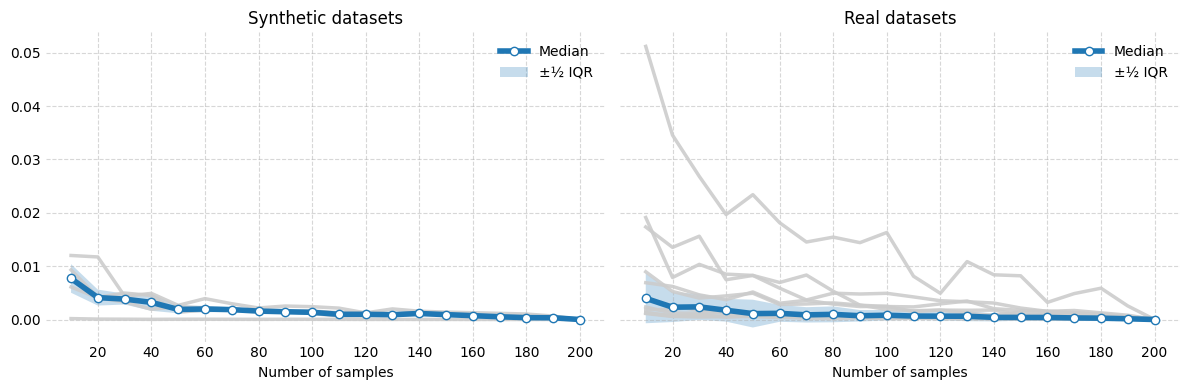

In [32]:
def plot_two_panel_convergence(per_ds_synth, agg_synth, per_ds_real, agg_real,
                               value_col="err_median",
                               ylabel="|S_mM(B) - S_mM(B_max)|  (↓)",
                               title_left="Synthetic", title_right="Real",
                               B_grid=None):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    def panel(ax, per_ds, agg, title, show_ylabel=False):
        for ds, g in per_ds.groupby("dataset"):
            ax.plot(g["B"], g[value_col],
                    color="0.8", linewidth=2.5, alpha=0.9)

        ax.plot(
            agg["B"], agg["median"],
            marker="o", markerfacecolor="white",
            linewidth=4, label="Median"
        )

        ax.fill_between(
            agg["B"],
            agg["median"] - 0.5 * agg["iqr"],
            agg["median"] + 0.5 * agg["iqr"],
            alpha=0.25, label="±½ IQR"
        )

        ax.set_title(title)
        ax.set_xlabel("Number of samples")

        if show_ylabel:
            ax.set_ylabel(ylabel)

        if B_grid is not None:
            ticks = [b for b in B_grid if b % 20 == 0]
            ax.set_xticks(ticks)

        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(frameon=False, loc="upper right")

        for side in ["top", "right", "left", "bottom"]:
            ax.spines[side].set_visible(False)

        ax.tick_params(axis="both", length=0)

    panel(axes[0], per_ds_synth, agg_synth,
          f"{title_left}",
          show_ylabel=True)

    panel(axes[1], per_ds_real, agg_real,
          f"{title_right}",
          show_ylabel=False)

    plt.tight_layout()
    plt.show()

plot_two_panel_convergence(
    per_ds_synth, agg_synth,
    per_ds_real, agg_real,
    value_col="err_median",
    ylabel="",
    title_left="Synthetic datasets",
    title_right="Real datasets",
    B_grid=B_grid,
)

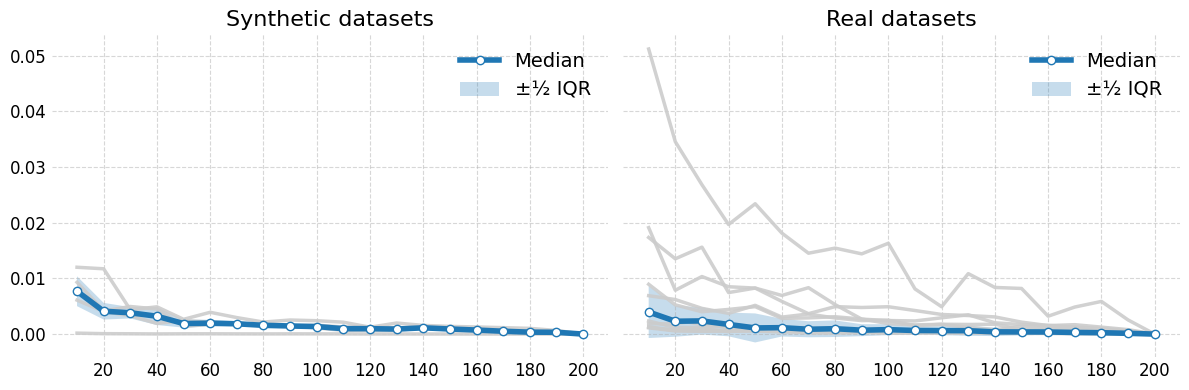

In [36]:
def plot_two_panel_convergence(per_ds_synth, agg_synth, per_ds_real, agg_real,
                               value_col="err_median",
                               ylabel="|S_mM(B) - S_mM(B_max)|  (↓)",
                               title_left="Synthetic", title_right="Real",
                               B_grid=None,
                               title_size=16,
                               label_size=14,
                               tick_size=12,
                               legend_size=14):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    def panel(ax, per_ds, agg, title, show_ylabel=False):
        for ds, g in per_ds.groupby("dataset"):
            ax.plot(g["B"], g[value_col],
                    color="0.8", linewidth=2.5, alpha=0.9)

        ax.plot(
            agg["B"], agg["median"],
            marker="o", markerfacecolor="white",
            linewidth=4, label="Median"
        )

        ax.fill_between(
            agg["B"],
            agg["median"] - 0.5 * agg["iqr"],
            agg["median"] + 0.5 * agg["iqr"],
            alpha=0.25, label="±½ IQR"
        )

        ax.set_title(title, fontsize=title_size)
        ax.set_xlabel("", fontsize=label_size)

        if show_ylabel:
            ax.set_ylabel(ylabel, fontsize=label_size)

        if B_grid is not None:
            ticks = [b for b in B_grid if b % 20 == 0]
            ax.set_xticks(ticks)

        ax.grid(True, linestyle="--", alpha=0.5)

        ax.legend(frameon=False, loc="upper right", fontsize=legend_size)

        for side in ["top", "right", "left", "bottom"]:
            ax.spines[side].set_visible(False)

        ax.tick_params(axis="both", length=0, labelsize=tick_size)

    panel(axes[0], per_ds_synth, agg_synth, f"{title_left}", show_ylabel=True)
    panel(axes[1], per_ds_real, agg_real, f"{title_right}", show_ylabel=False)

    plt.tight_layout()
    plt.show()

plot_two_panel_convergence(
    per_ds_synth, agg_synth,
    per_ds_real, agg_real,
    value_col="err_median",
    ylabel="",
    title_left="Synthetic datasets",
    title_right="Real datasets",
    B_grid=B_grid,
)